In [17]:
import pandas as pd

df = pd.read_csv('Microsoft_Stock.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


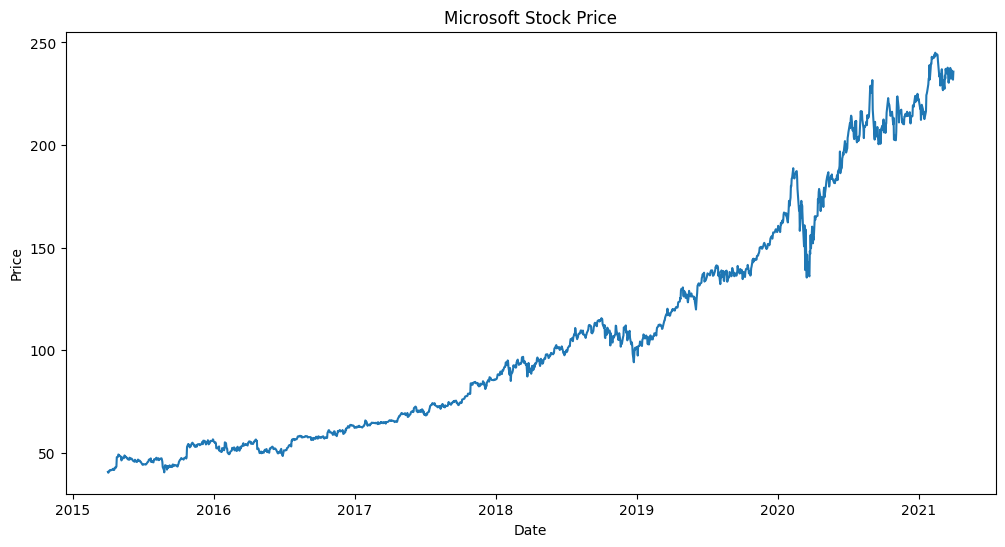

                      Open   High    Low  Close    Volume
Date                                                     
2015-04-01 16:00:00  40.60  40.76  40.31  40.72  36865322
2015-04-02 16:00:00  40.66  40.74  40.12  40.29  37487476
2015-04-06 16:00:00  40.34  41.78  40.18  41.55  39223692
2015-04-07 16:00:00  41.61  41.91  41.31  41.53  28809375
2015-04-08 16:00:00  41.48  41.69  41.04  41.42  24753438
              Open         High          Low        Close        Volume
count  1511.000000  1511.000000  1511.000000  1511.000000  1.511000e+03
mean    107.385976   108.437472   106.294533   107.422091  3.019863e+07
std      56.691333    57.382276    55.977155    56.702299  1.425266e+07
min      40.340000    40.740000    39.720000    40.290000  1.016120e+05
25%      57.860000    58.060000    57.420000    57.855000  2.136213e+07
50%      93.990000    95.100000    92.920000    93.860000  2.662962e+07
75%     139.440000   140.325000   137.825000   138.965000  3.431962e+07
max     245.030000

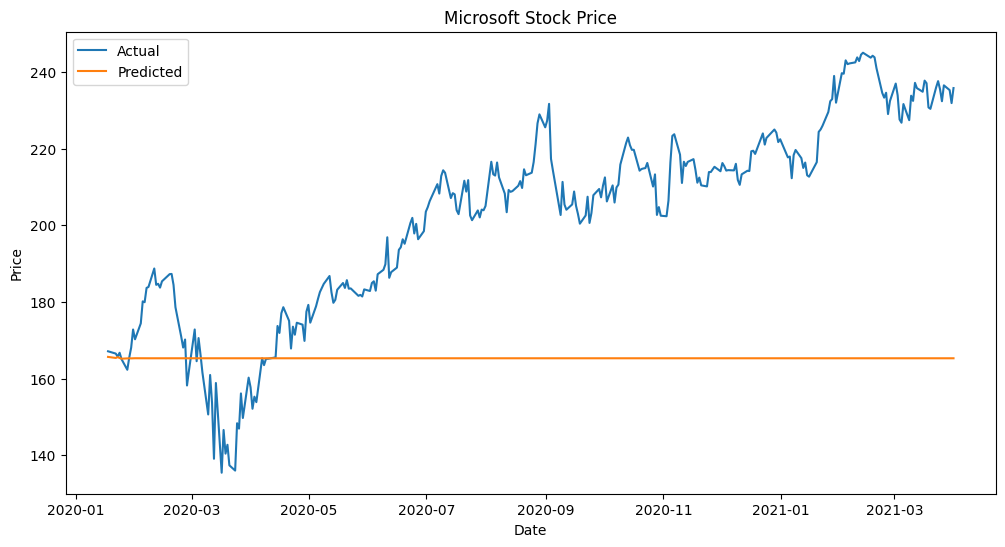

In [18]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# Loading the dataset
data = pd.read_csv('Microsoft_Stock.csv')

# Converting the date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Setting the date column as the index
data.set_index('Date', inplace=True)

# Visualizing the data
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title('Microsoft Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Performing EDA
print(data.head())
print(data.describe())

# Splitting the data into train and test sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Training the model
model = ARIMA(train['Close'], order=(5,1,0))
model_fit = model.fit()

# Making predictions
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)

# Evaluating the model
mse = mean_squared_error(test['Close'], predictions)
rmse = np.sqrt(mse)
print('RMSE: %.2f' % rmse)

# Visualizing the predictions
plt.figure(figsize=(12,6))
plt.plot(test.index, test['Close'], label='Actual')
plt.plot(test.index, predictions, label='Predicted')
plt.title('Microsoft Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


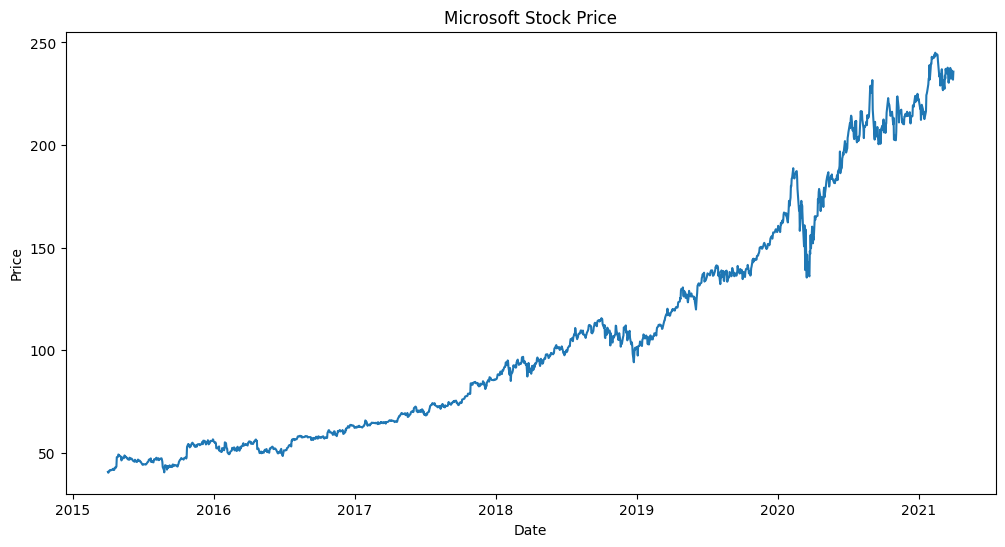

                      Open   High    Low  Close    Volume
Date                                                     
2015-04-01 16:00:00  40.60  40.76  40.31  40.72  36865322
2015-04-02 16:00:00  40.66  40.74  40.12  40.29  37487476
2015-04-06 16:00:00  40.34  41.78  40.18  41.55  39223692
2015-04-07 16:00:00  41.61  41.91  41.31  41.53  28809375
2015-04-08 16:00:00  41.48  41.69  41.04  41.42  24753438
              Open         High          Low        Close        Volume
count  1511.000000  1511.000000  1511.000000  1511.000000  1.511000e+03
mean    107.385976   108.437472   106.294533   107.422091  3.019863e+07
std      56.691333    57.382276    55.977155    56.702299  1.425266e+07
min      40.340000    40.740000    39.720000    40.290000  1.016120e+05
25%      57.860000    58.060000    57.420000    57.855000  2.136213e+07
50%      93.990000    95.100000    92.920000    93.860000  2.662962e+07
75%     139.440000   140.325000   137.825000   138.965000  3.431962e+07
max     245.030000

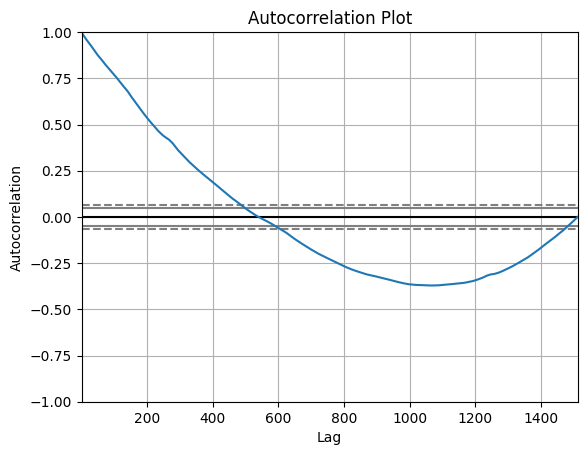

<Figure size 640x480 with 0 Axes>

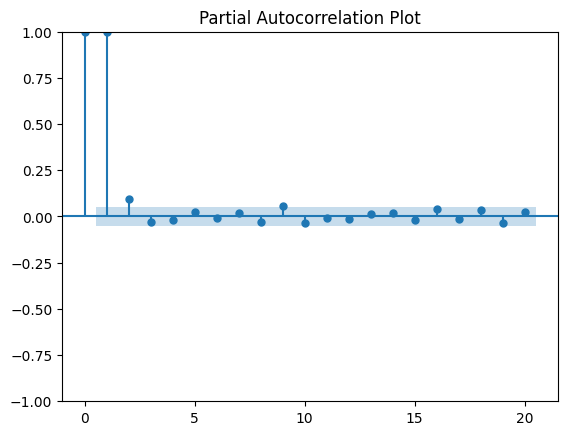

In [19]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_pacf

# Loading the dataset
data = pd.read_csv('Microsoft_Stock.csv')

# Converting the date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Setting the date column as the index
data.set_index('Date', inplace=True)

# Visualizing the data
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title('Microsoft Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Performing EDA
print(data.head())
print(data.describe())

# Analyze autocorrelation and partial autocorrelation plots to determine p, d, and q
plt.figure()
autocorrelation_plot(data['Close'])
plt.title('Autocorrelation Plot')
plt.show()

plt.figure()
plot_pacf(data['Close'], lags=20)
plt.title('Partial Autocorrelation Plot')
plt.show()

RMSE: 44.67


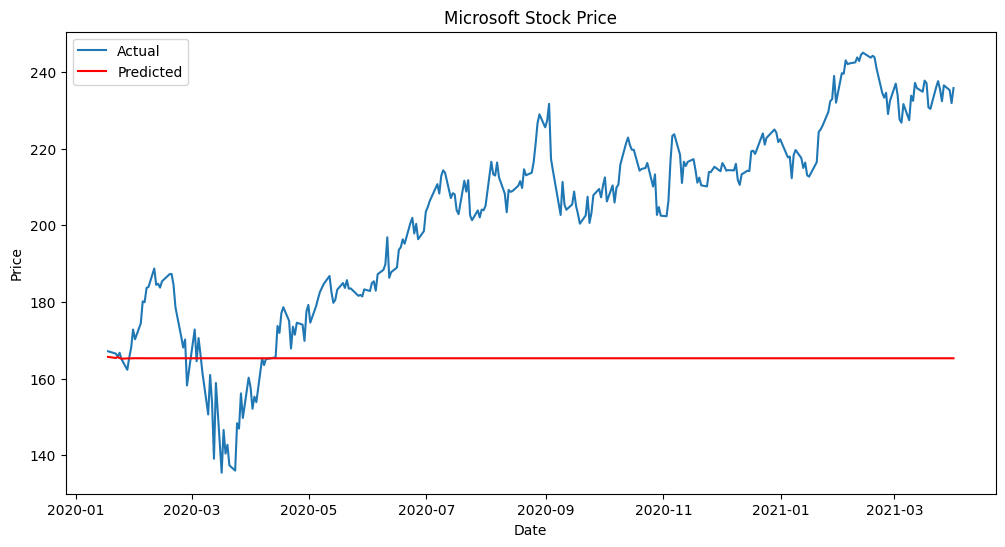

In [20]:
# Splitting the data into train and test sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Training the model with the optimal p, d, and q values
# You may need to modify the order based on the autocorrelation and partial autocorrelation plots
model = ARIMA(train['Close'], order=(5, 1, 0))
model_fit = model.fit()

# Making predictions
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Evaluating the model
mse = mean_squared_error(test['Close'], predictions)
rmse = np.sqrt(mse)
print('RMSE: %.2f' % rmse)

# Visualizing the predictions
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Close'], label='Actual')
plt.plot(test.index, predictions, label='Predicted', color='r')
plt.title('Microsoft Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

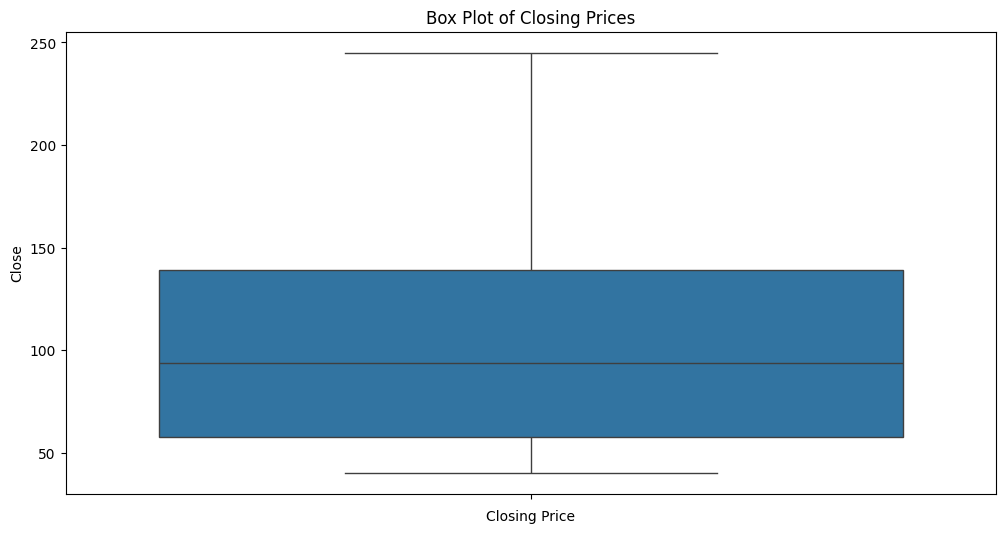

In [21]:
import seaborn as sns
from scipy import stats

# Box plot to visualize the distribution of closing prices
plt.figure(figsize=(12, 6))
sns.boxplot(data['Close'])
plt.title('Box Plot of Closing Prices')
plt.xlabel('Closing Price')
plt.show()

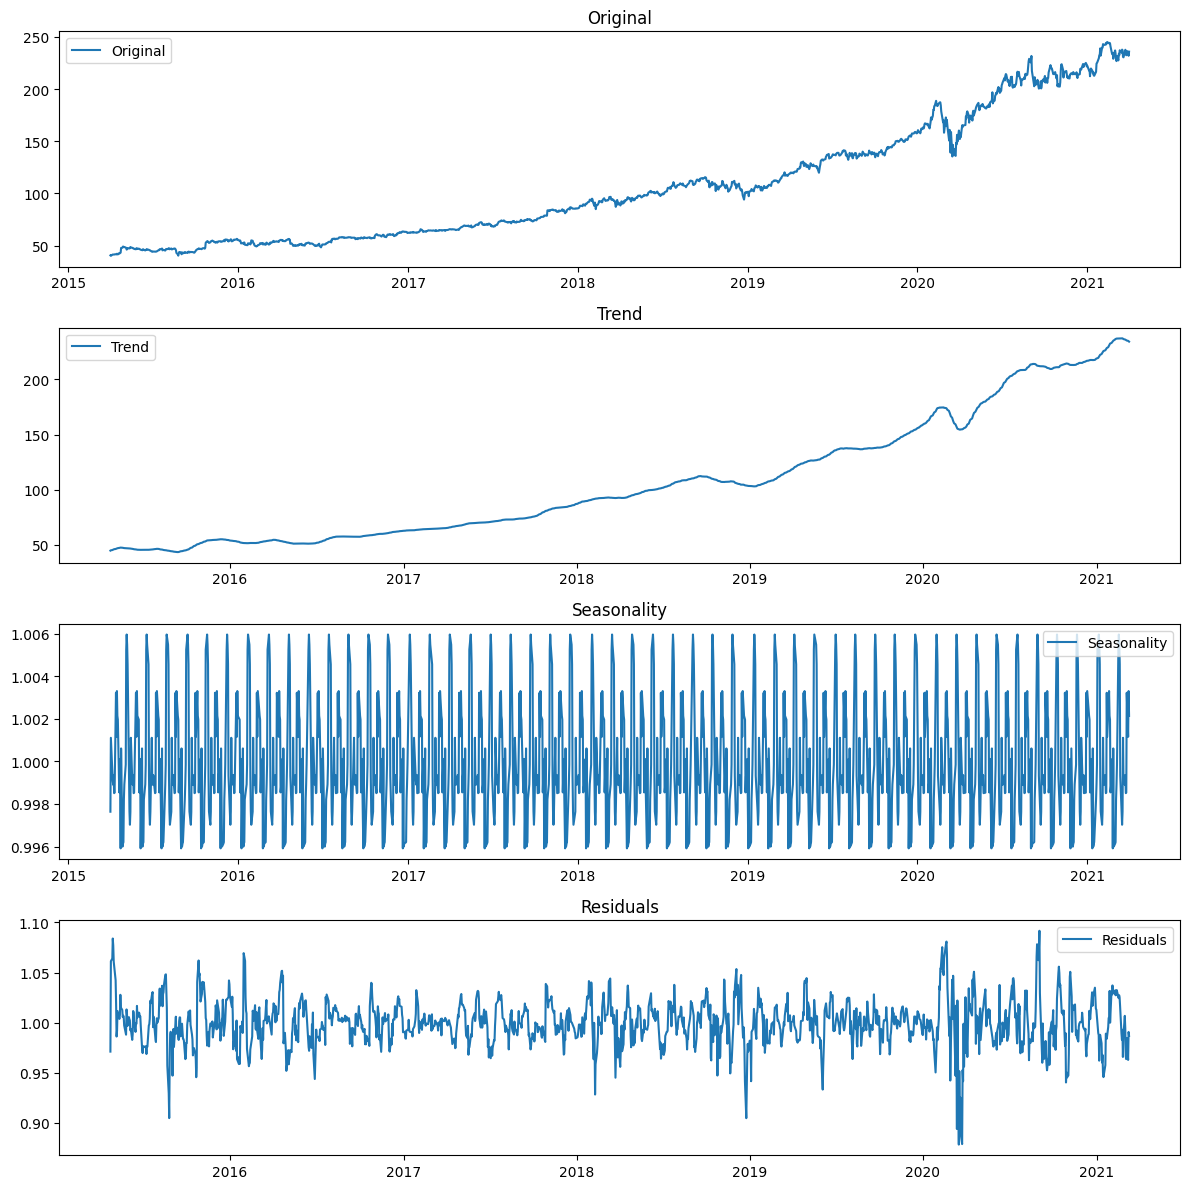

In [22]:
# Seasonal decomposition of the time series (trend, seasonality, and residuals)
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(data['Close'], model='multiplicative', period=30)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12, 12))

plt.subplot(411)
plt.plot(data['Close'], label='Original')
plt.legend(loc='best')
plt.title('Original')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.title('Trend')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.title('Seasonality')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.title('Residuals')

plt.tight_layout()
plt.show()

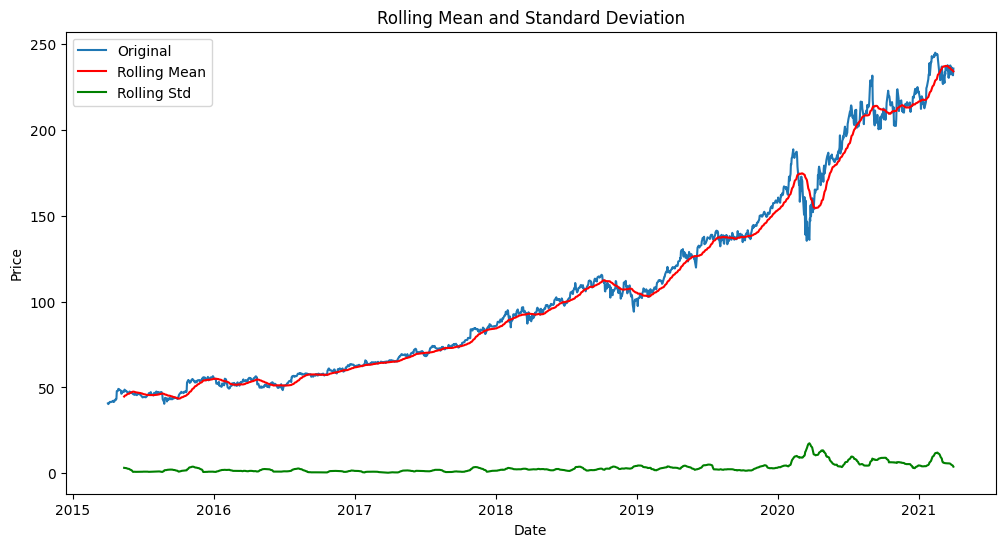

In [23]:
# Rolling mean and standard deviation
rolling_mean = data['Close'].rolling(window=30).mean()
rolling_std = data['Close'].rolling(window=30).std()

plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='r')
plt.plot(rolling_std, label='Rolling Std', color='g')
plt.legend(loc='best')
plt.title('Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

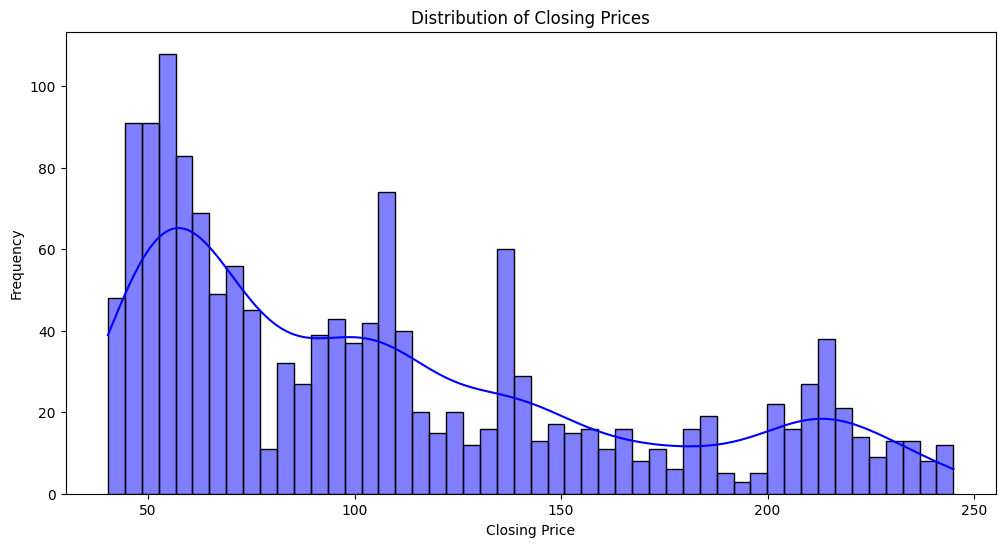

In [24]:
# Distribution plot of the closing prices
plt.figure(figsize=(12, 6))
sns.histplot(data['Close'], kde=True, bins=50, color='blue')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

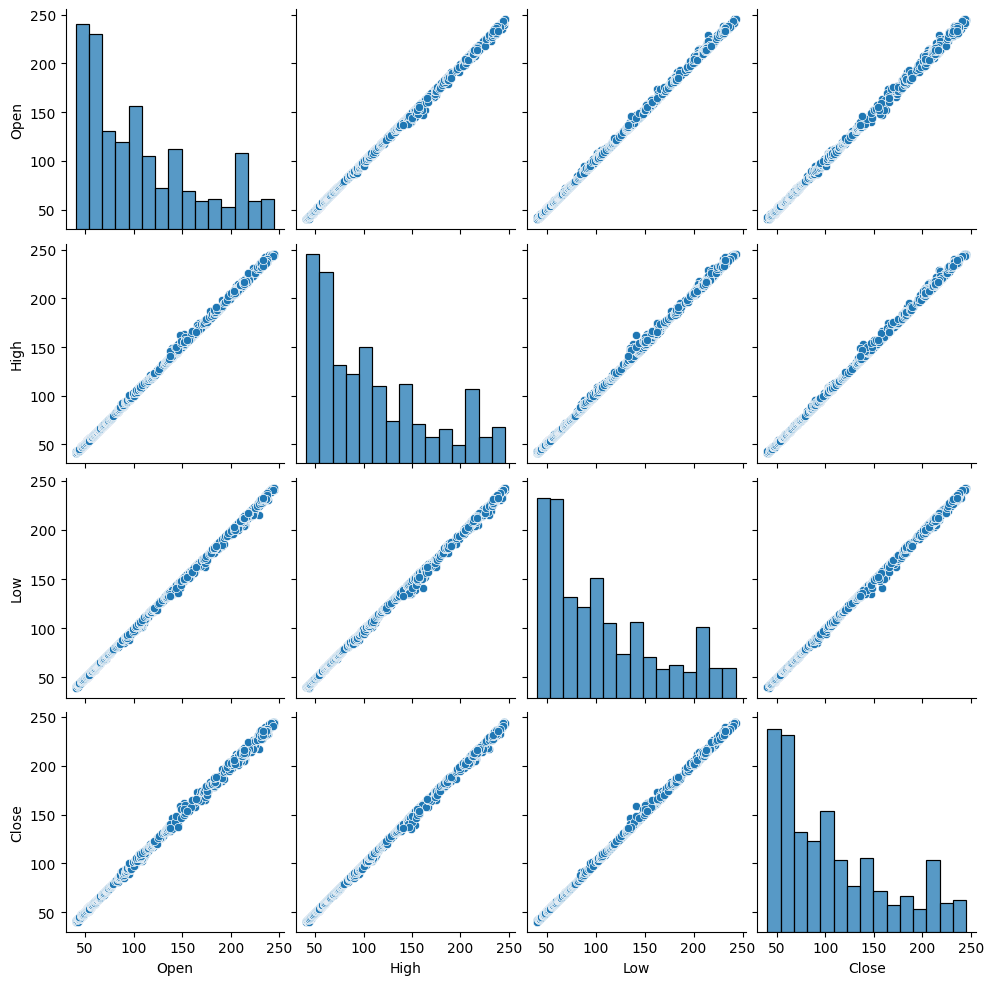

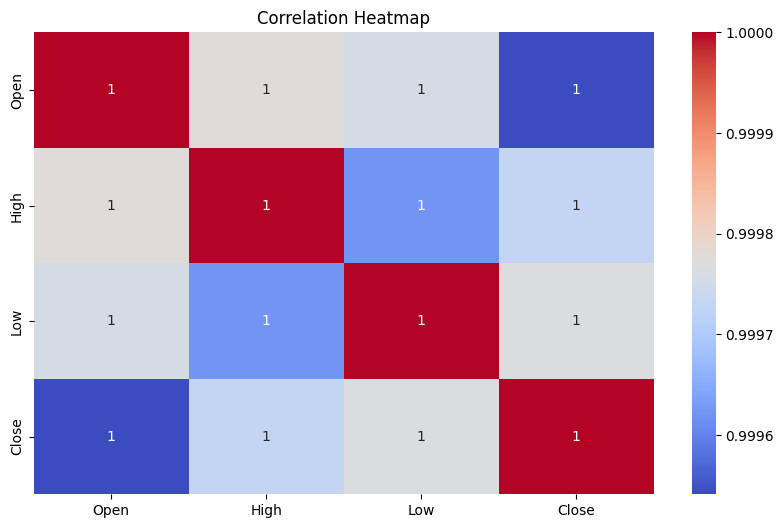

In [25]:
# Scatter plot matrix to visualize the relationship between Open, High, Low, and Close prices
sns.pairplot(data[['Open', 'High', 'Low', 'Close']])
plt.show()

# Heatmap to visualize the correlation between Open, High, Low, and Close prices
plt.figure(figsize=(10, 6))
sns.heatmap(data[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

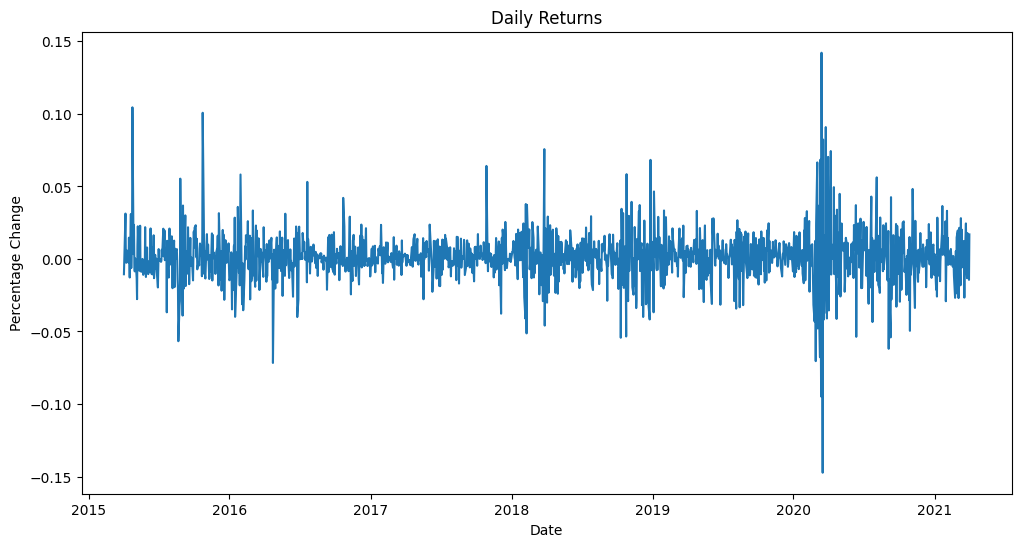

In [26]:
# Daily returns
daily_returns = data['Close'].pct_change().dropna()

plt.figure(figsize=(12, 6))
plt.plot(daily_returns)
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.show()

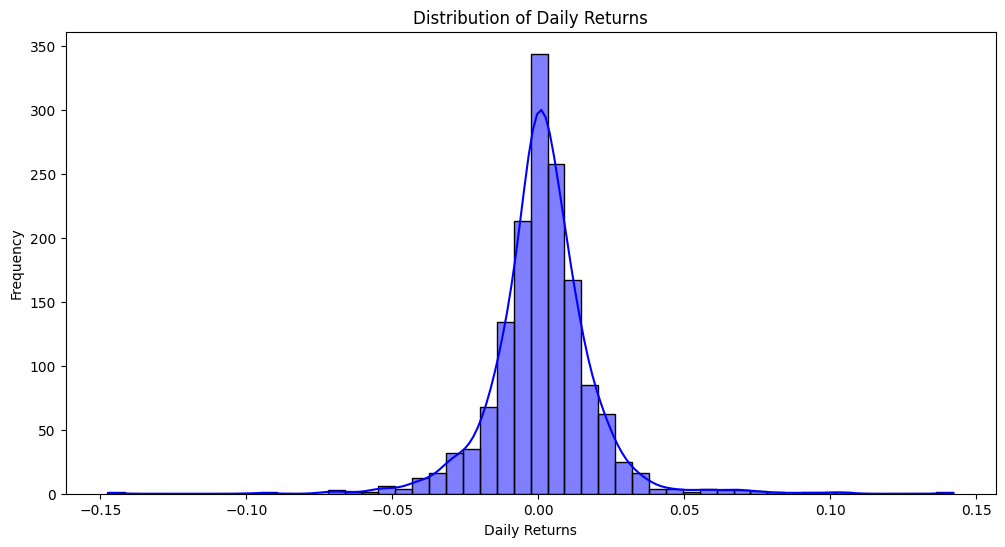

In [27]:
# Distribution plot of the daily returns
plt.figure(figsize=(12, 6))
sns.histplot(daily_returns, kde=True, bins=50, color='blue')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.show()

In [28]:
!pip install mplfinance --quiet

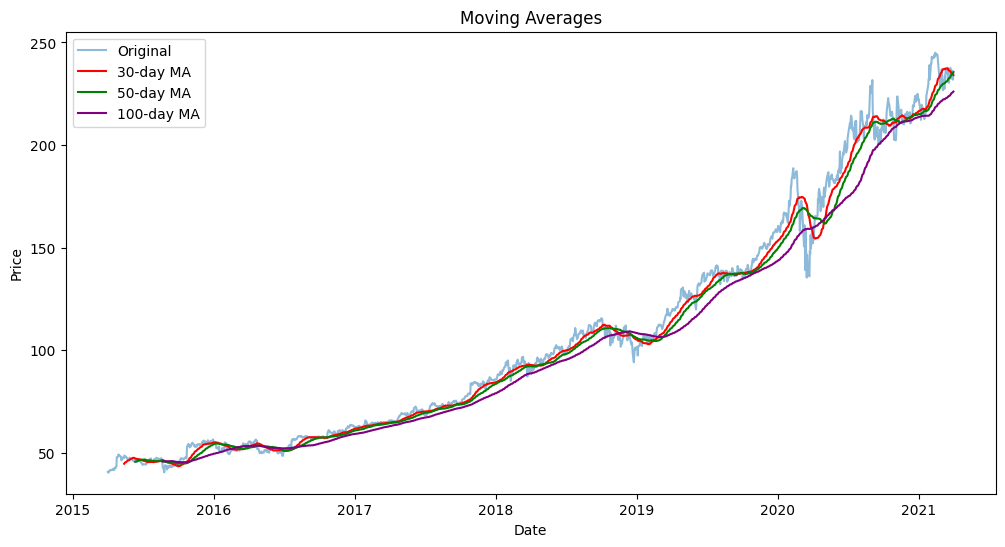

In [29]:
# Importing additional libraries
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates

# Compute moving averages for 30, 50, and 100 days
data['30_day_MA'] = data['Close'].rolling(window=30).mean()
data['50_day_MA'] = data['Close'].rolling(window=50).mean()
data['100_day_MA'] = data['Close'].rolling(window=100).mean()

# Plot moving averages
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Original', alpha=0.5)
plt.plot(data['30_day_MA'], label='30-day MA', color='r')
plt.plot(data['50_day_MA'], label='50-day MA', color='g')
plt.plot(data['100_day_MA'], label='100-day MA', color='purple')
plt.legend(loc='best')
plt.title('Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

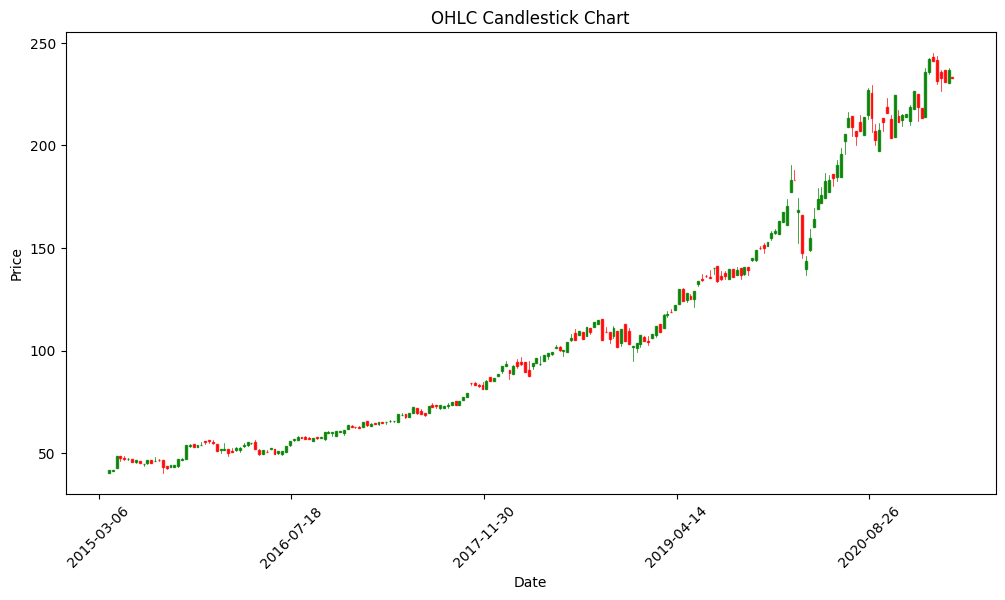

In [30]:
# OHLC (Open, High, Low, Close) chart using candlesticks
ohlc_data = data[['Open', 'High', 'Low', 'Close']].resample('10D').ohlc().reset_index()
ohlc_data['Date'] = ohlc_data['Date'].map(mdates.date2num)

fig, ax = plt.subplots(figsize=(12, 6))
candlestick_ohlc(ax, ohlc_data.values, width=5, colorup='g', colordown='r', alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.title('OHLC Candlestick Chart')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

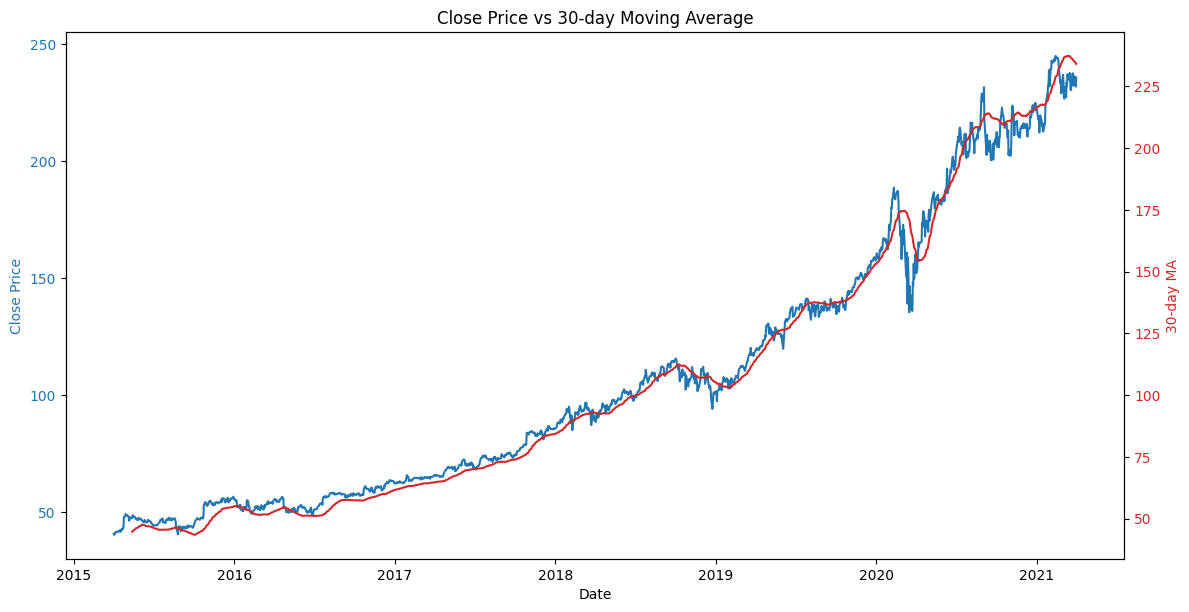

In [32]:
# Comparing the actual close price with the 30-day moving average
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color=color)
ax1.plot(data.index, data['Close'], label='Close', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('30-day MA', color=color)  # we already handled the x-label with ax1
ax2.plot(data.index, data['30_day_MA'], label='30-day MA', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Close Price vs 30-day Moving Average')
plt.show()

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Load the dataset
data = pd.read_csv('Microsoft_Stock.csv')

# Convert the date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Set the date column as the index
data.set_index('Date', inplace=True)

# Split the data into train and test sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Find the optimal order (p, d, q) for ARIMA model based on AIC or other criteria
# Here, we use the order (5, 1, 0) as an example
order = (5, 1, 0)

# Train the ARIMA model
model = ARIMA(train['Close'], order=order)
#to put it simply, ARIMA Is a statistical model used for time series forecasting that combines autoregressive (AR) and moving average (MA) components.
model_fit = model.fit()

# Make predictions
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Evaluate the model using mean squared error
mse = mean_squared_error(test['Close'], predictions)
rmse = np.sqrt(mse)
print('RMSE: %.2f' % rmse)

RMSE: 44.67


In [36]:
import itertools

# Define the range of p, d, and q values to try
p = range(0, 6)
d = range(0, 3)
q = range(0, 6)

# Generate all combinations of p, d, and q values
pdq_combinations = list(itertools.product(p, d, q))

# Function to find the best ARIMA model based on AIC (Akaike Information Criterion)
def find_best_arima(train_data, pdq_values):
    best_aic = float('inf')
    best_order = None

    for order in pdq_values:
        try:
            model = ARIMA(train_data, order=order)
            model_fit = model.fit()
            aic = model_fit.aic

            if aic < best_aic:
                best_aic = aic
                best_order = order

        except:
            continue

    return best_order, best_aic

# Find the best ARIMA model
best_order, best_aic = find_best_arima(train['Close'], pdq_combinations)
print(f"Best ARIMA order: {best_order} with AIC: {best_aic}")

# Train the ARIMA model with the best order
model = ARIMA(train['Close'], order=best_order)
model_fit = model.fit()

# Make predictions
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Evaluate the model using mean squared error
mse = mean_squared_error(test['Close'], predictions)
rmse = np.sqrt(mse)
print('RMSE: %.2f' % rmse)

Best ARIMA order: (5, 2, 1) with AIC: 3918.801366925401
RMSE: 17.09


In [37]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Assuming data is already loaded, preprocessed, and split into train and test

# Train the SARIMA model (use appropriate seasonal_order, e.g., (0, 0, 0, 12))
model = SARIMAX(train['Close'], order=best_order, seasonal_order=(0, 0, 0, 12))
model_fit = model.fit()

# Make predictions
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Evaluate the model
mse = mean_squared_error(test['Close'], predictions)
rmse = np.sqrt(mse)
print('RMSE: %.2f' % rmse)

RMSE: 17.09


In [38]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Load the dataset
data = pd.read_csv('Microsoft_Stock.csv', parse_dates=['Date'])

# Split the data into train and test sets
train = data[data['Date'] < '2020-01-01']
test = data[data['Date'] >= '2020-01-01']

# Scale the data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train['Close'].values.reshape(-1, 1))
test_scaled = scaler.transform(test['Close'].values.reshape(-1, 1))

# Prepare the input data for LSTM
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    # Add extra data points for the test set to match the number of predictions
    for i in range(look_back, len(data)):
        X.append(data[(i - look_back):i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


look_back = 10
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# Reshape the input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], look_back, 1))
X_test = np.reshape(X_test, (X_test.shape[0], look_back, 1))

# Build and train the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(look_back, 1), activation='relu', return_sequences=True))
model.add(LSTM(64, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=50, batch_size=32)

# Evaluate the model on test data
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Test RMSE:', rmse)

# # Visualize the predictions
# import matplotlib.pyplot as plt
# x_values = test['Date'][-len(y_test):]

# plt.plot(x_values, y_test, label='True')
# plt.plot(x_values, y_pred, label='Predicted')


# plt.title('Microsoft Stock Price Prediction')
# plt.xlabel('Date')
# plt.ylabel('Stock Price')
# plt.legend()
# plt.show()


2026-02-14 17:43:11.267623: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-14 17:43:13.074076: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-14 17:43:18.064049: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Epoch 1/50


2026-02-14 17:43:18.535826: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0240
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1436e-04
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0905e-04
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.9786e-04
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0526e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0069e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8770e-04
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8947e-04
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.9202e-04
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.0274e-04
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.7395e-04
Epoch 12/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.6922e-04
Epoch 13/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.5497e-04
Epoch 14/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8505e-04
Epoch 15/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8m

Trial 20 Complete [00h 00m 50s]
val_loss: 0.00031735553056932986

Best val_loss So Far: 0.0002963620936498046
Total elapsed time: 00h 14m 05s
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Test RMSE: 0.05262464394008319


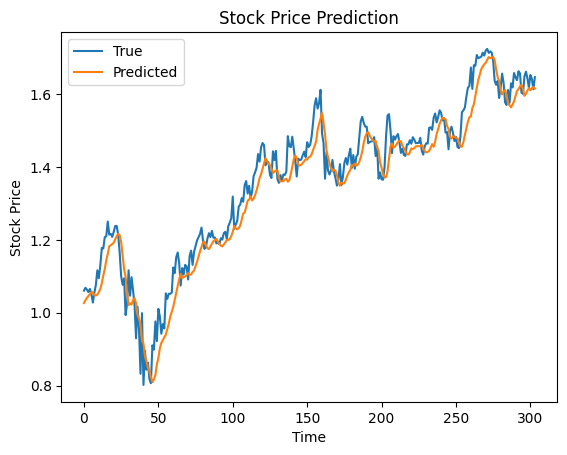

In [ ]:
%pip install keras-tuner --quiet

import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

# Assuming data is already loaded, preprocessed, and split into train and test

# Scale the data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['Close', 'Volume']].values)
test_scaled = scaler.transform(test[['Close', 'Volume']].values)

# Prepare the input data for LSTM
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)
#we create 


def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=256, step=32), 
                   input_shape=(X_train.shape[1], X_train.shape[2]), 
                   activation=hp.Choice('activation_1', values=['relu', 'tanh']), 
                   return_sequences=True))
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=256, step=32), 
                   activation=hp.Choice('activation_2', values=['relu', 'tanh'])))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer=hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop']))
    return model

tuner = RandomSearch(build_model, 
                     objective='val_loss', 
                     max_trials=20, 
                     executions_per_trial=2, 
                     directory='tuner_results', 
                     project_name='stock_price_prediction')

look_back = 10
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# Reshape the input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], look_back, X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], look_back, X_test.shape[2]))

tuner.search(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=10)])

# Get the best model and evaluate on test data
best_model = tuner.get_best_models(num_models=1)[0]
y_pred = best_model.predict(X_test)
# y_pred = scaler.inverse_transform(y_pred.reshape(-1))
# y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Test RMSE:', rmse)

# # Visualize the predictions
plt.plot(y_test, label='True')
plt.plot(y_pred, label='Predicted')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()